In [145]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')
import matplotlib.patches as mpatches
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [2]:
# Load the IPL datasets
matches = pd.read_csv("matches.csv")
deliveries = pd.read_csv("deliveries.csv")

### Understanding the Dataset

In [3]:
matches.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


In [4]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN


In [5]:
print(matches.shape)

(636, 18)


In [6]:
print(deliveries.shape)

(150460, 21)


In [7]:
print(matches.columns)

Index(['id', 'season', 'city', 'date', 'team1', 'team2', 'toss_winner',
       'toss_decision', 'result', 'dl_applied', 'winner', 'win_by_runs',
       'win_by_wickets', 'player_of_match', 'venue', 'umpire1', 'umpire2',
       'umpire3'],
      dtype='object')


In [8]:
print(deliveries.columns)

Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batsman', 'non_striker', 'bowler', 'is_super_over', 'wide_runs',
       'bye_runs', 'legbye_runs', 'noball_runs', 'penalty_runs',
       'batsman_runs', 'extra_runs', 'total_runs', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='object')


In [9]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 636 entries, 0 to 635
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               636 non-null    int64  
 1   season           636 non-null    int64  
 2   city             629 non-null    object 
 3   date             636 non-null    object 
 4   team1            636 non-null    object 
 5   team2            636 non-null    object 
 6   toss_winner      636 non-null    object 
 7   toss_decision    636 non-null    object 
 8   result           636 non-null    object 
 9   dl_applied       636 non-null    int64  
 10  winner           633 non-null    object 
 11  win_by_runs      636 non-null    int64  
 12  win_by_wickets   636 non-null    int64  
 13  player_of_match  633 non-null    object 
 14  venue            636 non-null    object 
 15  umpire1          635 non-null    object 
 16  umpire2          635 non-null    object 
 17  umpire3         

In [10]:
deliveries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150460 entries, 0 to 150459
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          150460 non-null  int64 
 1   inning            150460 non-null  int64 
 2   batting_team      150460 non-null  object
 3   bowling_team      150460 non-null  object
 4   over              150460 non-null  int64 
 5   ball              150460 non-null  int64 
 6   batsman           150460 non-null  object
 7   non_striker       150460 non-null  object
 8   bowler            150460 non-null  object
 9   is_super_over     150460 non-null  int64 
 10  wide_runs         150460 non-null  int64 
 11  bye_runs          150460 non-null  int64 
 12  legbye_runs       150460 non-null  int64 
 13  noball_runs       150460 non-null  int64 
 14  penalty_runs      150460 non-null  int64 
 15  batsman_runs      150460 non-null  int64 
 16  extra_runs        150460 non-null  int

In [11]:
matches.isnull().sum()

id                   0
season               0
city                 7
date                 0
team1                0
team2                0
toss_winner          0
toss_decision        0
result               0
dl_applied           0
winner               3
win_by_runs          0
win_by_wickets       0
player_of_match      3
venue                0
umpire1              1
umpire2              1
umpire3            636
dtype: int64

In [12]:
deliveries.isnull().sum()

match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batsman                  0
non_striker              0
bowler                   0
is_super_over            0
wide_runs                0
bye_runs                 0
legbye_runs              0
noball_runs              0
penalty_runs             0
batsman_runs             0
extra_runs               0
total_runs               0
player_dismissed    143022
dismissal_kind      143022
fielder             145091
dtype: int64

### Data Cleaning

In [13]:
matches.drop('umpire3', axis=1, inplace=True)

In [14]:
print(matches.columns)

Index(['id', 'season', 'city', 'date', 'team1', 'team2', 'toss_winner',
       'toss_decision', 'result', 'dl_applied', 'winner', 'win_by_runs',
       'win_by_wickets', 'player_of_match', 'venue', 'umpire1', 'umpire2'],
      dtype='object')


In [15]:
# Remove matches without a result
matches.dropna(subset=['winner'], inplace=True)

In [18]:
#Removing City as we cannot predict the city correctly which leads to false information to ml
matches.dropna(subset=['city'], inplace=True)

In [19]:
# Fill missing umpire names with 'Unknown' as this is not important and we use them for analysis pupose only.
matches['umpire1'].fillna('Unknown', inplace=True)
matches['umpire2'].fillna('Unknown', inplace=True)

In [20]:
matches.isnull().sum()

id                 0
season             0
city               0
date               0
team1              0
team2              0
toss_winner        0
toss_decision      0
result             0
dl_applied         0
winner             0
win_by_runs        0
win_by_wickets     0
player_of_match    0
venue              0
umpire1            0
umpire2            0
dtype: int64

### Checking Duplicate

In [23]:
matches.duplicated().sum()

np.int64(0)

In [24]:
deliveries.duplicated().sum()

np.int64(1)

In [25]:
deliveries.drop_duplicates(inplace=True)

In [26]:
deliveries.duplicated().sum()

np.int64(0)

### Exploratory Data Analysis (EDA)

**Seasonal Analysis**

In [29]:
season_matches = matches['season'].value_counts().sort_index() #Tells how many matches played in the respective seasons
print(season_matches)

season
2008    58
2009    57
2010    60
2011    72
2012    74
2013    76
2014    53
2015    57
2016    60
2017    59
Name: count, dtype: int64


*Matches Played Per Season*

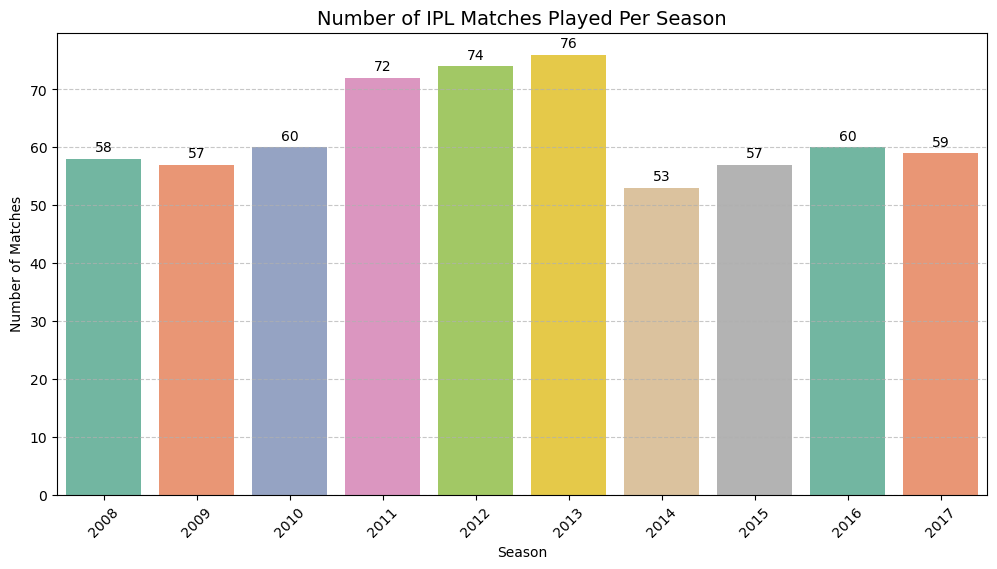

In [43]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
        x=season_matches.index,
        y=season_matches.values,
        palette='Set2'
    )
for i in ax.containers:
    ax.bar_label(i, padding=3)

plt.title('Number of IPL Matches Played Per Season', fontsize=14)
plt.xlabel('Season')
plt.ylabel('Number of Matches')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

**Team Performance Analysis**

In [50]:
team_wins = matches['winner'].value_counts()  #Tells how many times each tam has won
print(team_wins)

winner
Mumbai Indians                 92
Kolkata Knight Riders          77
Chennai Super Kings            77
Royal Challengers Bangalore    72
Kings XI Punjab                69
Rajasthan Royals               63
Delhi Daredevils               61
Sunrisers Hyderabad            40
Deccan Chargers                29
Rising Pune Supergiant         15
Gujarat Lions                  13
Pune Warriors                  12
Kochi Tuskers Kerala            6
Name: count, dtype: int64


In [ ]:
# Combining the team with same one as the name has been differed
matches.replace('Rising Pune Supergiants',
                'Rising Pune Supergiant',
                inplace=True)

deliveries.replace('Rising Pune Supergiants',
                   'Rising Pune Supergiant',
                   inplace=True)

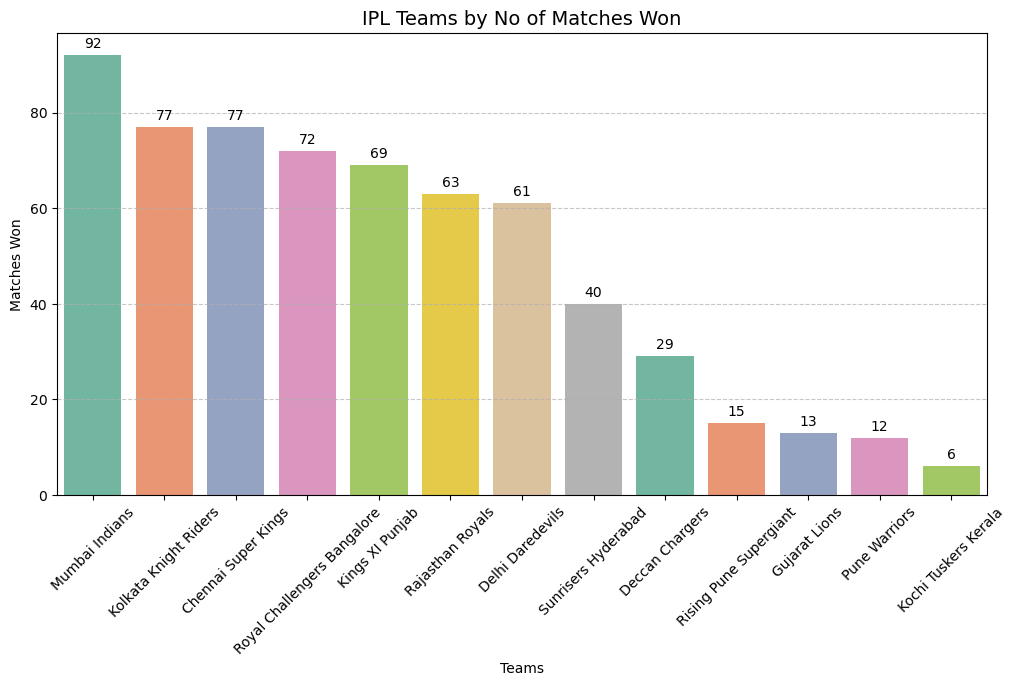

In [52]:
plt.figure(figsize=(12,6))
ax = sns.barplot(
        x=team_wins.index,
        y=team_wins.values,
        palette='Set2'
    )
for i in ax.containers:
    ax.bar_label(i, padding=3)

plt.title('IPL Teams by No of Matches Won', fontsize=14)
plt.xlabel('Teams')
plt.ylabel('Matches Won')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

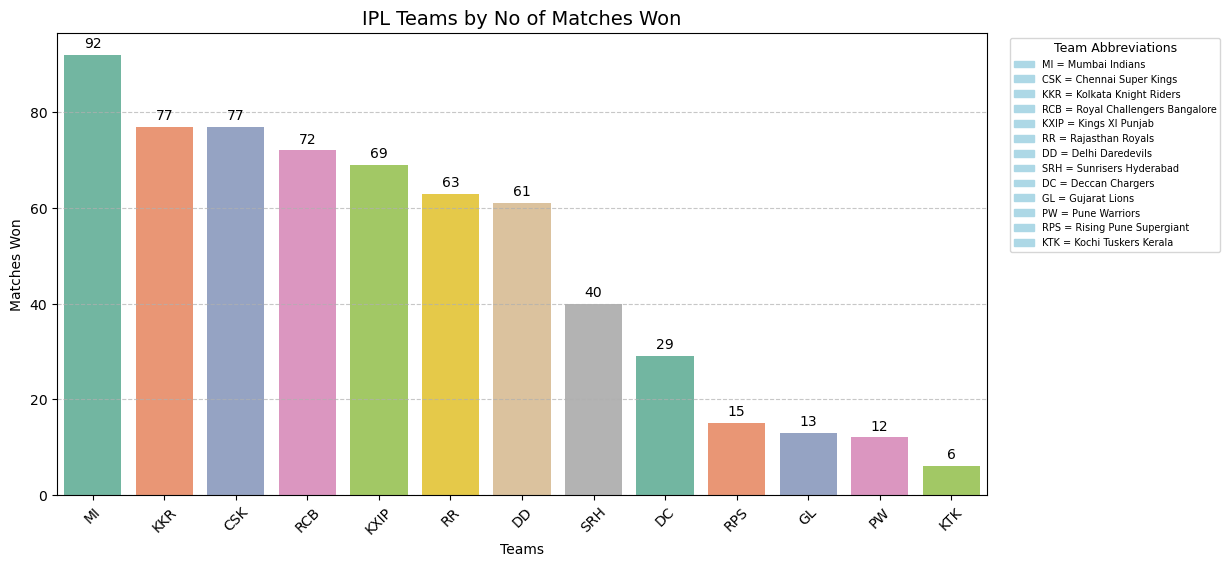

In [66]:
team_abbr = {
    'Mumbai Indians': 'MI',
    'Chennai Super Kings': 'CSK',
    'Kolkata Knight Riders': 'KKR',
    'Royal Challengers Bangalore': 'RCB',
    'Kings XI Punjab': 'KXIP',
    'Rajasthan Royals': 'RR',
    'Delhi Daredevils': 'DD',
    'Sunrisers Hyderabad': 'SRH',
    'Deccan Chargers': 'DC',
    'Gujarat Lions': 'GL',
    'Pune Warriors': 'PW',
    'Rising Pune Supergiant': 'RPS',
    'Kochi Tuskers Kerala': 'KTK'
}
team_wins_short = team_wins.copy()
team_wins_short.index = [team_abbr.get(team, team) for team in team_wins.index]
plt.figure(figsize=(12,6))
ax = sns.barplot(
        x=team_wins_short.index,
        y=team_wins_short.values,
        palette='Set2'
    )
for i in ax.containers:
    ax.bar_label(i, padding=3)

plt.title('IPL Teams by No of Matches Won', fontsize=14)
plt.xlabel('Teams')
plt.ylabel('Matches Won')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
# Create custom legend
legend_patches = [
    mpatches.Patch(color='lightblue', label=f'{abbr} = {team}')
    for team, abbr in team_abbr.items()
]

plt.legend(
    handles=legend_patches,    #legend entries
    title='Team Abbreviations',
    bbox_to_anchor = (1.02,1),
    loc='upper left',
    fontsize=7,
    title_fontsize=9)
plt.show()

**Toss Decision Analysis**

In [67]:
toss_decision = matches['toss_decision'].value_counts()
print(toss_decision)

toss_decision
field    357
bat      269
Name: count, dtype: int64


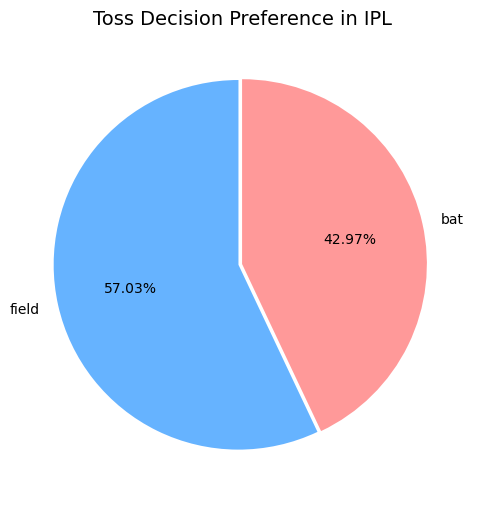

In [80]:
plt.figure(figsize=(12,6))

plt.pie(
    toss_decision.values,
    labels=toss_decision.index,
    autopct='%1.2f%%',
    startangle=90,
    colors=['#66b3ff', '#ff9999'],
    explode=(0.02, 0)
)

plt.title('Toss Decision Preference in IPL', fontsize=14)
plt.show()

*Insights:*

*The analysis indicates that a majority of IPL teams prefer to field first after winning the toss, suggesting that teams generally favor chasing targets.*

In [83]:
matches['toss_match_win'] = np.where(
    matches['toss_winner'] == matches['winner'],
    'Yes',
    'No'
)
toss_match_result = matches['toss_match_win'].value_counts()
print(toss_match_result)

toss_match_win
Yes    322
No     304
Name: count, dtype: int64


*Toss Impact on Match Result*

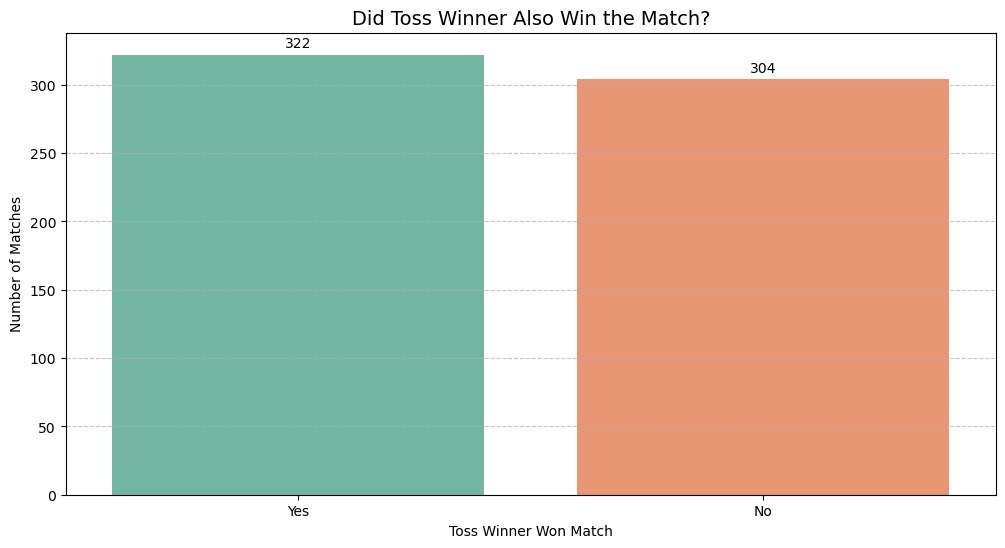

In [88]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    x=toss_match_result.index,
    y=toss_match_result.values,
    palette='Set2'
)
for i in ax.containers:
    ax.bar_label(i, padding=3)
plt.title('Did Toss Winner Also Win the Match?', fontsize=14)
plt.xlabel('Toss Winner Won Match')
plt.ylabel('Number of Matches')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

*Insights:*

*The Analysis show that team wiinning the toss won approximately 51.4% of the matches*

**Top Batsman Analysis**

In [89]:
batsman = deliveries.groupby('batsman')['batsman_runs'].sum()
top_batsman = batsman.sort_values(ascending=False,).head(10)
print(top_batsman)

batsman
SK Raina          4548
V Kohli           4423
RG Sharma         4207
G Gambhir         4132
DA Warner         4014
RV Uthappa        3778
CH Gayle          3651
S Dhawan          3561
MS Dhoni          3560
AB de Villiers    3486
Name: batsman_runs, dtype: int64


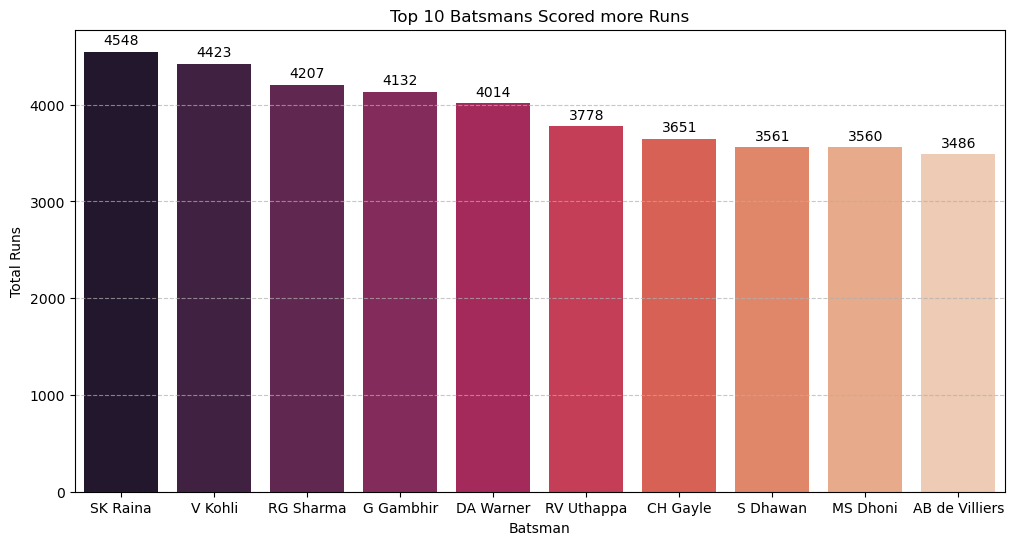

In [97]:
plt.figure(figsize=(12,6))
ax = sns.barplot(
    x = top_batsman.index,
    y = top_batsman.values,
    palette = 'rocket'
)
for i in ax.containers:
    ax.bar_label(i,padding=3)
plt.title('Top 10 Batsmans Scored more Runs')
plt.xlabel('Batsman')
plt.ylabel('Total Runs')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Top Bowler Analysis**

In [98]:
wickets = deliveries[deliveries['player_dismissed'].notnull()]
top_bowlers = wickets['bowler'].value_counts().head(10)
print(top_bowlers)

bowler
SL Malinga         170
A Mishra           142
DJ Bravo           137
Harbhajan Singh    136
PP Chawla          133
R Vinay Kumar      125
A Nehra            121
Z Khan             119
B Kumar            117
R Ashwin           110
Name: count, dtype: int64


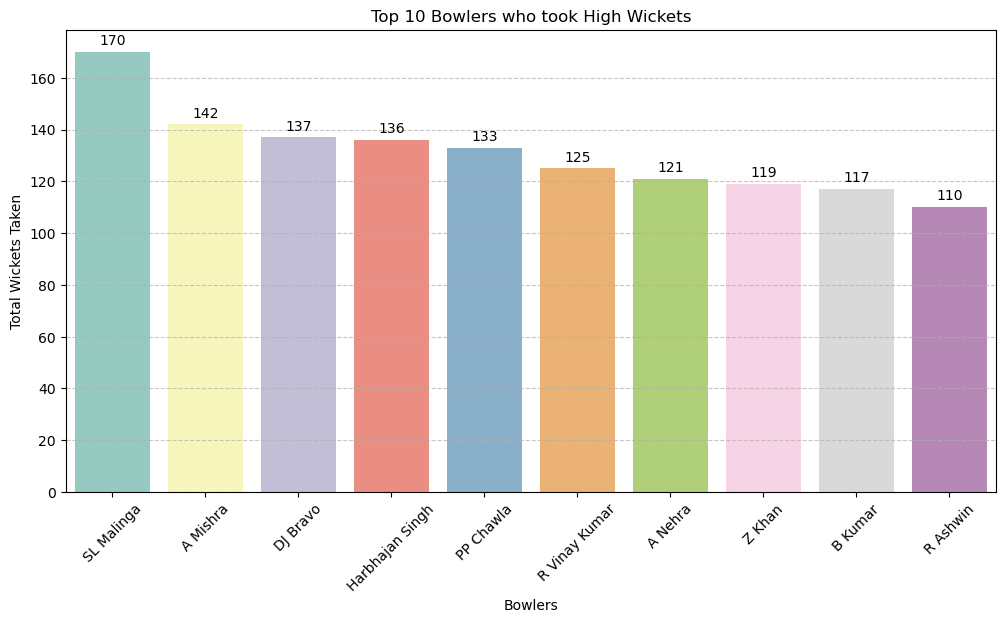

In [103]:
plt.figure(figsize=(12,6))
ax = sns.barplot(
    x = top_bowlers.index,
    y = top_bowlers.values,
    palette = 'Set3'
)
for i in ax.containers:
    ax.bar_label(i,padding=3)
plt.title('Top 10 Bowlers who took High Wickets')
plt.xlabel('Bowlers')
plt.ylabel('Total Wickets Taken')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.show()

### High Scoring Matches Analysis (Runs = 200+)

In [104]:
team_scores = deliveries.groupby(['match_id', 'inning', 'batting_team'])['total_runs'].sum().reset_index()
high_scores = team_scores[team_scores['total_runs'] >= 200]
print(high_scores.head())

    match_id  inning                 batting_team  total_runs
0          1       1          Sunrisers Hyderabad         207
16         9       1             Delhi Daredevils         205
38        20       1  Royal Challengers Bangalore         213
62        32       1          Sunrisers Hyderabad         207
72        36       1          Sunrisers Hyderabad         209


In [106]:
high_score_teams = high_scores['batting_team'].value_counts()
print(high_score_teams) # Tells how many times the team has scored 200+ in the matches

batting_team
Royal Challengers Bangalore    13
Chennai Super Kings            12
Kings XI Punjab                11
Mumbai Indians                  9
Sunrisers Hyderabad             6
Rajasthan Royals                6
Delhi Daredevils                4
Kolkata Knight Riders           4
Gujarat Lions                   1
Deccan Chargers                 1
Name: count, dtype: int64


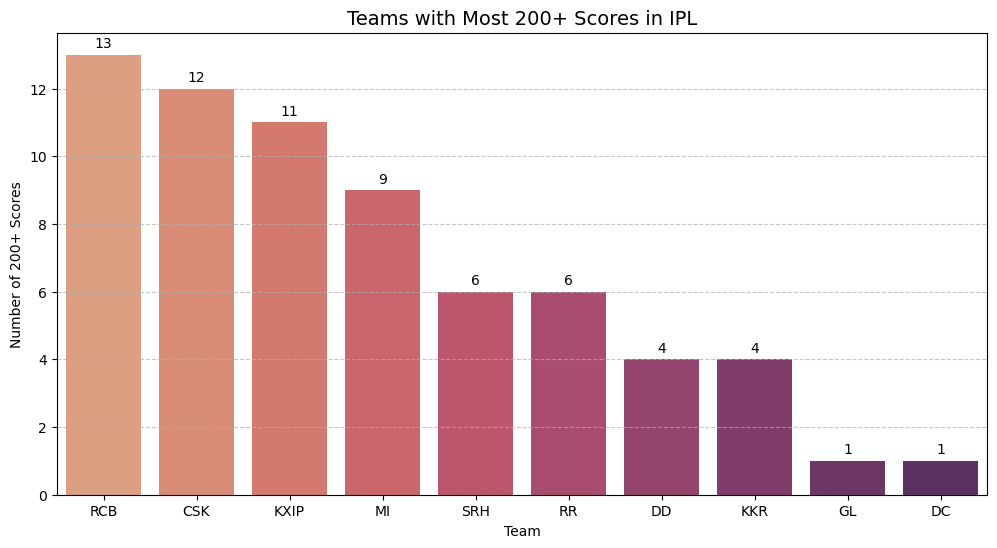

In [110]:
team_abbr = {
    'Mumbai Indians': 'MI',
    'Chennai Super Kings': 'CSK',
    'Kolkata Knight Riders': 'KKR',
    'Royal Challengers Bangalore': 'RCB',
    'Kings XI Punjab': 'KXIP',
    'Rajasthan Royals': 'RR',
    'Delhi Daredevils': 'DD',
    'Sunrisers Hyderabad': 'SRH',
    'Deccan Chargers': 'DC',
    'Gujarat Lions': 'GL',
    'Pune Warriors': 'PW',
    'Rising Pune Supergiant': 'RPS',
    'Kochi Tuskers Kerala': 'KTK'
}
high_scores = high_score_teams.copy()
high_scores.index = [team_abbr.get(team, team) for team in high_scores.index]



plt.figure(figsize=(12, 6))
ax = sns.barplot(
    x=high_scores.index,
    y=high_scores.values,
    palette='flare'
)
for container in ax.containers:
    ax.bar_label(container, padding=3)
plt.title('Teams with Most 200+ Scores in IPL', fontsize=14)
plt.xlabel('Team')
plt.ylabel('Number of 200+ Scores')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Super Over Analysis

In [112]:
matches['result']

0      normal
1      normal
2      normal
3      normal
4      normal
        ...  
631    normal
632    normal
633    normal
634    normal
635    normal
Name: result, Length: 626, dtype: object

In [116]:
super_over_matches = matches[matches['result'] == 'tie']
print("Total Super Over Matches:", super_over_matches.shape[0])
print(super_over_matches[['season', 'team1', 'team2', 'winner']])

Total Super Over Matches: 7
     season                        team1                        team2  \
33     2017                Gujarat Lions               Mumbai Indians   
125    2009             Rajasthan Royals        Kolkata Knight Riders   
189    2010              Kings XI Punjab          Chennai Super Kings   
387    2013  Royal Challengers Bangalore          Sunrisers Hyderabad   
400    2013             Delhi Daredevils  Royal Challengers Bangalore   
475    2014             Rajasthan Royals        Kolkata Knight Riders   
535    2015             Rajasthan Royals              Kings XI Punjab   

                          winner  
33                Mumbai Indians  
125             Rajasthan Royals  
189              Kings XI Punjab  
387          Sunrisers Hyderabad  
400  Royal Challengers Bangalore  
475             Rajasthan Royals  
535              Kings XI Punjab  


In [117]:
super_over_teams = pd.concat([                   # Doing concatination to combine and keep present teams
    super_over_matches['team1'],
    super_over_matches['team2']
])
super_over_team_count = super_over_teams.value_counts()
print(super_over_team_count)

Rajasthan Royals               3
Kings XI Punjab                2
Royal Challengers Bangalore    2
Kolkata Knight Riders          2
Gujarat Lions                  1
Delhi Daredevils               1
Mumbai Indians                 1
Chennai Super Kings            1
Sunrisers Hyderabad            1
Name: count, dtype: int64


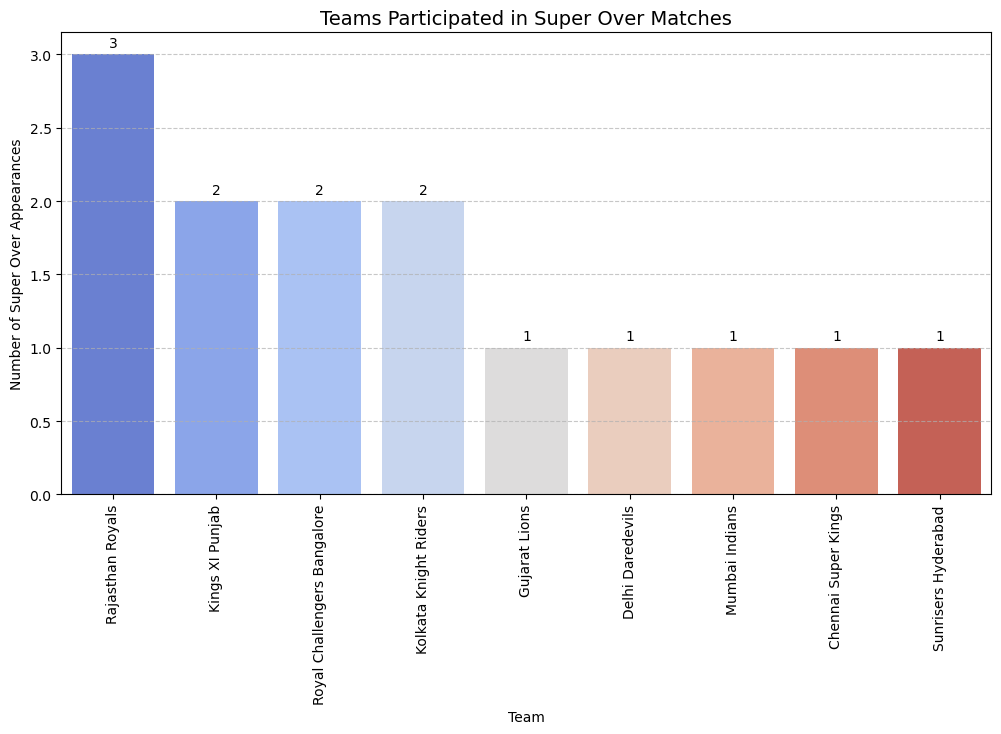

In [121]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=super_over_team_count.index,
    y=super_over_team_count.values,
    palette='coolwarm'
)
for container in ax.containers:
    ax.bar_label(container, padding=3)
plt.title('Teams Participated in Super Over Matches', fontsize=14)
plt.xlabel('Team')
plt.ylabel('Number of Super Over Appearances')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

### Umpire Trend Analysis

In [122]:
all_umpires = pd.concat([        # Combine the umpire columns
    matches['umpire1'],
    matches['umpire2']
])

In [123]:
top_umpires = all_umpires.value_counts().head(10)
print(top_umpires)

HDPK Dharmasena    84
S Ravi             83
AK Chaudhary       57
C Shamshuddin      56
SJA Taufel         55
Asad Rauf          51
M Erasmus          51
BR Doctrove        42
RE Koertzen        41
CK Nandan          41
Name: count, dtype: int64


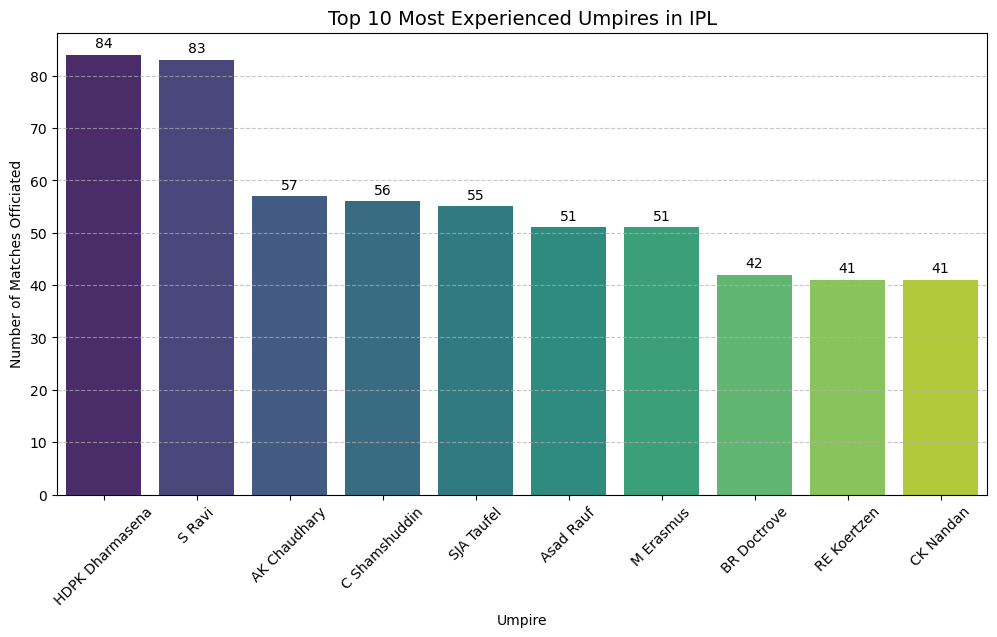

In [124]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    x=top_umpires.index,
    y=top_umpires.values,
    palette='viridis'
)
for container in ax.containers:
    ax.bar_label(container, padding=3)
plt.title('Top 10 Most Experienced Umpires in IPL', fontsize=14)
plt.xlabel('Umpire')
plt.ylabel('Number of Matches Officiated')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Orange Cap Analysis

*This means Season wise Highest Runs Scorer*

In [125]:
merged_data = pd.merge(
    deliveries,
    matches[['id', 'season']],
    left_on='match_id',
    right_on='id'
)
print(merged_data.head())

   match_id  inning         batting_team                 bowling_team  over  \
0         1       1  Sunrisers Hyderabad  Royal Challengers Bangalore     1   
1         1       1  Sunrisers Hyderabad  Royal Challengers Bangalore     1   
2         1       1  Sunrisers Hyderabad  Royal Challengers Bangalore     1   
3         1       1  Sunrisers Hyderabad  Royal Challengers Bangalore     1   
4         1       1  Sunrisers Hyderabad  Royal Challengers Bangalore     1   

   ball    batsman non_striker    bowler  is_super_over  ...  noball_runs  \
0     1  DA Warner    S Dhawan  TS Mills              0  ...            0   
1     2  DA Warner    S Dhawan  TS Mills              0  ...            0   
2     3  DA Warner    S Dhawan  TS Mills              0  ...            0   
3     4  DA Warner    S Dhawan  TS Mills              0  ...            0   
4     5  DA Warner    S Dhawan  TS Mills              0  ...            0   

   penalty_runs  batsman_runs  extra_runs  total_runs  player_

In [126]:
season_batsman_runs = merged_data.groupby(['season', 'batsman'])['batsman_runs'].sum().reset_index()
print(season_batsman_runs.head())

   season   batsman  batsman_runs
0    2008  A Chopra            42
1    2008  A Kumble            13
2    2008  A Mishra            37
3    2008  A Mukund             0
4    2008   A Nehra             3


In [127]:
orange_cap_idx = season_batsman_runs.groupby('season')['batsman_runs'].idxmax()
orange_cap_winners = season_batsman_runs.loc[orange_cap_idx]
print(orange_cap_winners)

      season       batsman  batsman_runs
115     2008      SE Marsh           616
229     2009     ML Hayden           572
446     2010  SR Tendulkar           617
502     2011      CH Gayle           608
684     2012      CH Gayle           733
910     2013    MEK Hussey           733
1088    2014    RV Uthappa           605
1145    2015     DA Warner           562
1380    2016       V Kohli           973
1419    2017     DA Warner           641


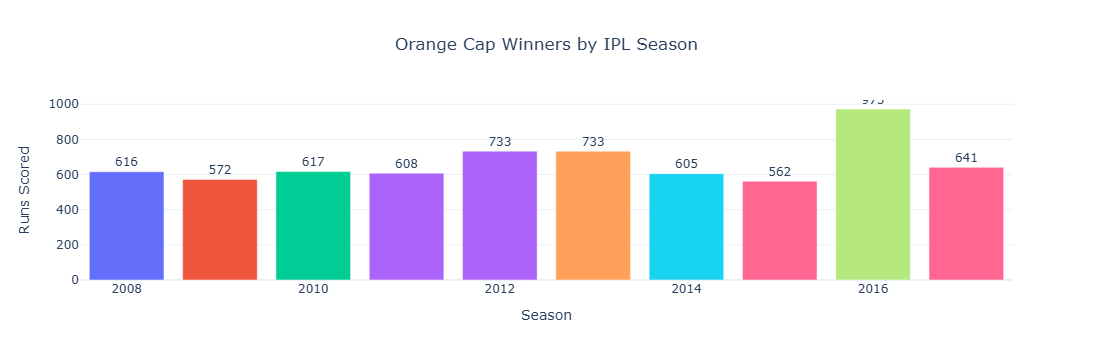

In [128]:
fig = px.bar(
    orange_cap_winners,
    x='season',
    y='batsman_runs',
    color='batsman',
    text='batsman_runs',
    hover_data=['batsman'],
    title='Orange Cap Winners by IPL Season',
    labels={
        'season': 'Season',
        'batsman_runs': 'Runs Scored',
        'batsman': 'Player'})
# Display run values on bars
fig.update_traces(
    textposition='outside'
)
fig.update_layout(
    xaxis_title='Season',
    yaxis_title='Runs Scored',
    title_x=0.5,
    showlegend=False,
    template='plotly_white'
)
fig.show()

### Purple Cap Analysis

*Season Wise Highest Wicket Takers in Bowlers*

In [129]:
season_wickets = merged_data[merged_data['player_dismissed'].notnull()]
season_bowler_wickets = season_wickets.groupby(['season', 'bowler']).size().reset_index(name='wickets')
print(season_bowler_wickets.head())

   season     bowler  wickets
0    2008   A Kumble        8
1    2008   A Mishra       11
2    2008    A Nehra       14
3    2008      A Nel        1
4    2008  AA Noffke        1


In [130]:
purple_cap_idx = season_bowler_wickets.groupby('season')['wickets'].idxmax()
purple_cap_winners = season_bowler_wickets.loc[purple_cap_idx]
print(purple_cap_winners)

     season         bowler  wickets
77     2008  Sohail Tanvir       24
157    2009       RP Singh       26
248    2010        PP Ojha       22
374    2011     SL Malinga       30
445    2012       M Morkel       30
517    2013       DJ Bravo       34
677    2014      SP Narine       21
706    2015       DJ Bravo       28
789    2016        B Kumar       24
877    2017        B Kumar       28


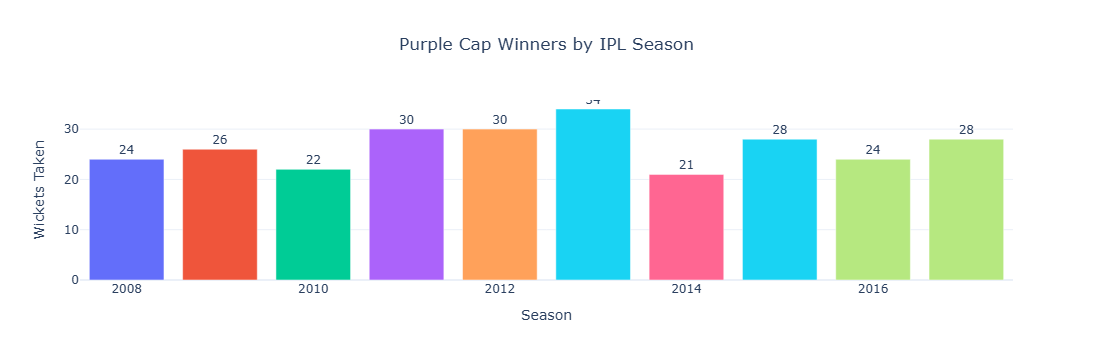

In [131]:
fig = px.bar(
    purple_cap_winners,
    x='season',
    y='wickets',
    color='bowler',
    text='wickets',
    hover_data=['bowler'],
    title='Purple Cap Winners by IPL Season',
    labels={
        'season': 'Season',
        'wickets': 'Wickets Taken',
        'bowler': 'Bowler'})
fig.update_traces(
    textposition='outside'
)
fig.update_layout(
    xaxis_title='Season',
    yaxis_title='Wickets Taken',
    title_x=0.5,
    showlegend=False,
    template='plotly_white'
)
fig.show()

### Player Comparision Modules

**Top 10 Players with Most Sixes**

In [132]:
sixes = deliveries[deliveries['batsman_runs'] == 6]
top_six_hitters = sixes['batsman'].value_counts().head(10)
print(top_six_hitters)

batsman
CH Gayle          266
SK Raina          174
RG Sharma         173
V Kohli           160
DA Warner         160
AB de Villiers    158
MS Dhoni          156
YK Pathan         149
KA Pollard        148
Yuvraj Singh      141
Name: count, dtype: int64


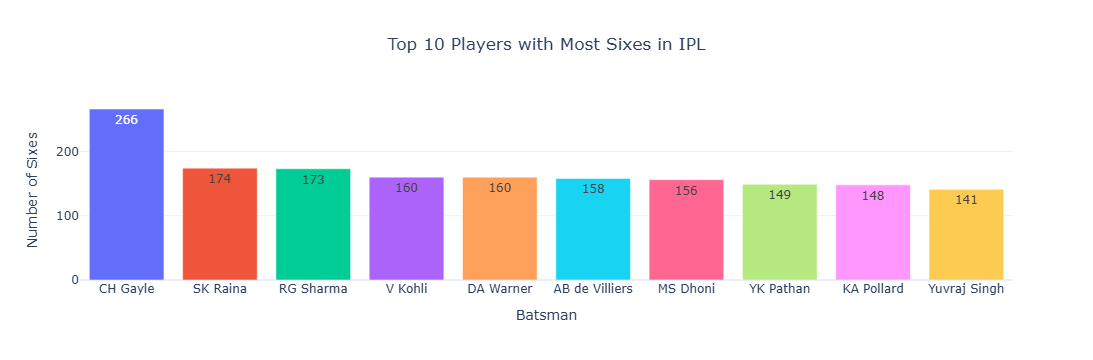

In [133]:
fig = px.bar(
    x=top_six_hitters.index,
    y=top_six_hitters.values,
    text=top_six_hitters.values,
    color=top_six_hitters.index,
    title='Top 10 Players with Most Sixes in IPL'
)
fig.update_layout(
    xaxis_title='Batsman',
    yaxis_title='Number of Sixes',
    showlegend=False,
    title_x=0.5,
    template='plotly_white'
)
fig.show()

**Top 10 Players with most 4's**

In [134]:
fours = deliveries[deliveries['batsman_runs'] == 4]
top_four_hitters = fours['batsman'].value_counts().head(10)
print(top_four_hitters)

batsman
G Gambhir     484
SK Raina      402
DA Warner     401
S Dhawan      401
V Kohli       384
RV Uthappa    377
RG Sharma     354
V Sehwag      334
AM Rahane     320
CH Gayle      297
Name: count, dtype: int64


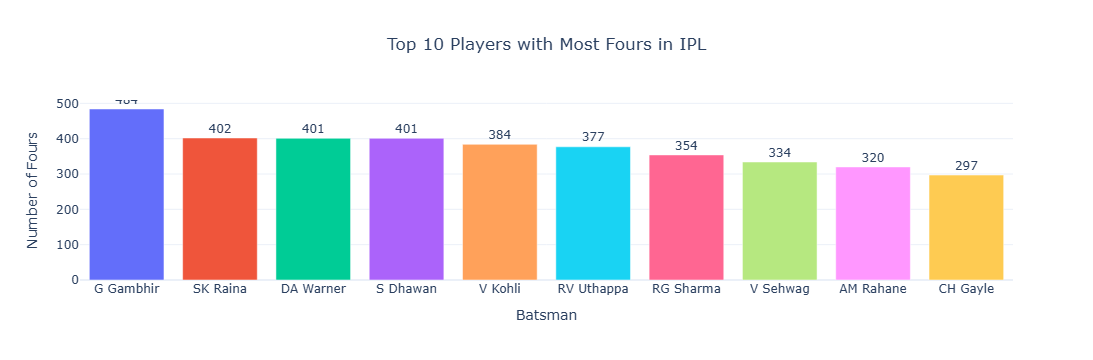

In [135]:
fig = px.bar(
    x=top_four_hitters.index,
    y=top_four_hitters.values,
    text=top_four_hitters.values,
    color=top_four_hitters.index,
    title='Top 10 Players with Most Fours in IPL')
fig.update_traces(textposition='outside')
fig.update_layout(
    xaxis_title='Batsman',
    yaxis_title='Number of Fours',
    showlegend=False,
    title_x=0.5,
    template='plotly_white'
)
fig.show()

### Strike Rate Analysis of Top Batsmen

In [136]:
runs = deliveries.groupby('batsman')['batsman_runs'].sum()    # Total runs Scored by each Batsmen
balls = deliveries.groupby('batsman').size()     # Total Balls he Faced
strike_rate_df = pd.DataFrame({
    'Runs': runs,
    'Balls': balls})
strike_rate_df = strike_rate_df[strike_rate_df['Runs'] >= 1000]
print(strike_rate_df.head())

                Runs  Balls
batsman                    
AB de Villiers  3486   2402
AC Gilchrist    2069   1555
AJ Finch        1604   1270
AM Rahane       3057   2602
AT Rayudu       2416   1964


In [137]:
strike_rate_df['Strike_Rate'] = (strike_rate_df['Runs'] / strike_rate_df['Balls']) * 100
top_strike_rates = strike_rate_df.sort_values(by='Strike_Rate',ascending=False).head(10)
print(top_strike_rates)

                Runs  Balls  Strike_Rate
batsman                                 
GJ Maxwell      1229    780   157.564103
V Sehwag        2728   1833   148.827059
AB de Villiers  3486   2402   145.129059
CH Gayle        3651   2532   144.194313
YK Pathan       2922   2076   140.751445
KA Pollard      2354   1674   140.621266
DA Warner       4014   2902   138.318401
DA Miller       1563   1135   137.709251
SK Raina        4548   3369   134.995548
SR Watson       2628   1949   134.838379


### Prediction Module

In [138]:
ml_data = matches[[
        'team1',
        'team2',
        'toss_winner',
        'toss_decision',
        'venue',
        'winner'
    ]]
print(ml_data.head())

                         team1                        team2  \
0          Sunrisers Hyderabad  Royal Challengers Bangalore   
1               Mumbai Indians       Rising Pune Supergiant   
2                Gujarat Lions        Kolkata Knight Riders   
3       Rising Pune Supergiant              Kings XI Punjab   
4  Royal Challengers Bangalore             Delhi Daredevils   

                   toss_winner toss_decision  \
0  Royal Challengers Bangalore         field   
1       Rising Pune Supergiant         field   
2        Kolkata Knight Riders         field   
3              Kings XI Punjab         field   
4  Royal Challengers Bangalore           bat   

                                       venue                       winner  
0  Rajiv Gandhi International Stadium, Uppal          Sunrisers Hyderabad  
1    Maharashtra Cricket Association Stadium       Rising Pune Supergiant  
2     Saurashtra Cricket Association Stadium        Kolkata Knight Riders  
3                     Holkar

In [140]:
print(ml_data.isnull().sum())    #Checking any missing value occured

team1            0
team2            0
toss_winner      0
toss_decision    0
venue            0
winner           0
dtype: int64


In [168]:
encoder = LabelEncoder()
for column in ml_data.columns:
    ml_data[column] = encoder.fit_transform(ml_data[column])
print(ml_data.head())

   team1  team2  toss_winner  toss_decision  venue  winner
0     12     11           11              1     22      12
1      7     10           10              1     15      10
2      3      6            6              1     24       6
3     10      4            4              1     10       4
4     11      2           11              0     13      11


In [143]:
# Features (Inputs)
X = ml_data.drop('winner', axis=1)
# Target (Output)
y = ml_data['winner']
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (626, 5)
Target Shape: (626,)


In [146]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)
print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

Training Features Shape: (500, 5)
Testing Features Shape: (126, 5)
Training Target Shape: (500,)
Testing Target Shape: (126,)


In [155]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

**Logistic Regression Model**

In [148]:
# Create model
lr_model = LogisticRegression(max_iter=1000)
# Train model
lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [152]:
y_pred = lr_model.predict(X_test)

In [159]:
accuracy = accuracy_score(y_test, y_pred)
print("Logistic Regression Accuracy:", accuracy)

Logistic Regression Accuracy: 0.23809523809523808


**Random Forest Model**

In [156]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.5555555555555556


In [158]:
models = ['Logistic Regression', 'Random Forest']
accuracies = [accuracy, rf_accuracy]

comparison_df = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracies
})
print(comparison_df)

                 Model  Accuracy
0  Logistic Regression  0.238095
1        Random Forest  0.555556


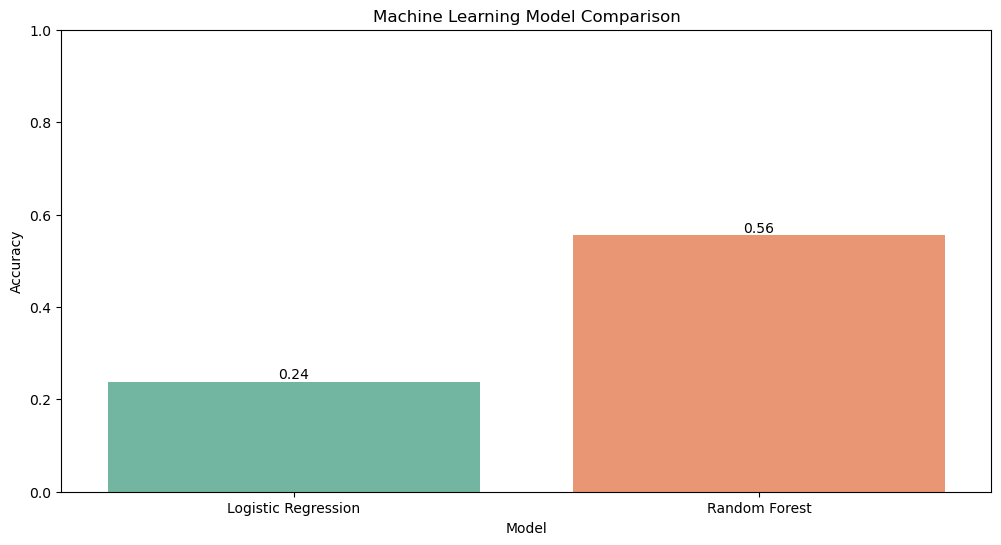

In [161]:
plt.figure(figsize=(12,6))
ax = sns.barplot(
    x='Model',
    y='Accuracy',
    data=comparison_df,
    palette='Set2'
)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')
plt.title('Machine Learning Model Comparison')
plt.ylabel('Accuracy')
plt.ylim(0,1)
plt.show()

In [ ]:
team1_encoder = LabelEncoder()
team2_encoder = LabelEncoder()
toss_winner_encoder = LabelEncoder()
toss_decision_encoder = LabelEncoder()
venue_encoder = LabelEncoder()
winner_encoder = LabelEncoder()

# Fit on original categorical data
team1_encoder.fit(matches['team1'])
team2_encoder.fit(matches['team2'])
toss_winner_encoder.fit(matches['toss_winner'])
toss_decision_encoder.fit(matches['toss_decision'])
venue_encoder.fit(matches['venue'])
winner_encoder.fit(matches['winner'])

In [169]:
def predict_winner(team1, team2, toss_winner,
                   toss_decision, venue):
    team1 = team1_encoder.transform([team1])[0]
    team2 = team2_encoder.transform([team2])[0]
    toss_winner = toss_winner_encoder.transform([toss_winner])[0]
    toss_decision = toss_decision_encoder.transform([toss_decision])[0]
    venue = venue_encoder.transform([venue])[0]
    input_data = [[team1, team2,
                   toss_winner,
                   toss_decision,
                   venue]]
    prediction = rf_model.predict(input_data)
    predicted_team = winner_encoder.inverse_transform(prediction)
    print("Predicted Winner:", predicted_team[0])

In [170]:
predict_winner(
    team1='Mumbai Indians',
    team2='Chennai Super Kings',
    toss_winner='Mumbai Indians',
    toss_decision='field',
    venue='Wankhede Stadium'
)

Predicted Winner: Mumbai Indians
